In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahamt/cube-ant-tillage/E2021-22 Cube Ant Tillage - Final Data File for Ag Data Commons.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mahamt/cube-ant-tillage/E2021-22 Cube Ant Tillage - Final Data File for Ag Data Commons.csv")

In [4]:
print(df.columns.tolist())

['ROW_ID', 'Year', 'Month', 'Day', 'Sample Week', 'Crop', 'Treatment', 'Block', 'Plot', 'Air_Temperature', 'Ground_Temperature', 'Soil_Temperature', 'Humidity', 'Egg_Start', 'Not_Eaten', 'Eaten', 'Proportion_Eaten', 'Abundance', 'Richness', 'Lasius_neoniger', 'Solenopsis_molesta', 'Formica_montana', 'Formica_rubicunda', 'Formica_subaenescens', 'Myrmica_americana', 'Temnothorax_ambiguus']


In [5]:
df.head()

,ROW_ID,Year,Month,Day,Sample Week,Crop,Treatment,Block,Plot,Air_Temperature,...,Proportion_Eaten,Abundance,Richness,Lasius_neoniger,Solenopsis_molesta,Formica_montana,Formica_rubicunda,Formica_subaenescens,Myrmica_americana,Temnothorax_ambiguus
0,1,2021,June,4,1,Soy,Till,a,1,24.1,...,0.11,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2021,June,4,1,Soy,Till,a,2,24.3,...,0.27,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2021,June,4,1,Soy,No Till,a,1,25.9,...,0.03,1,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2021,June,4,1,Soy,No Till,a,2,25.4,...,0.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2021,June,4,1,Corn,Till,a,1,24.0,...,0.70,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(768, 26)

In [7]:
df.columns

Index(['ROW_ID', 'Year', 'Month', 'Day', 'Sample Week', 'Crop', 'Treatment',
       'Block', 'Plot', 'Air_Temperature', 'Ground_Temperature',
       'Soil_Temperature', 'Humidity', 'Egg_Start', 'Not_Eaten', 'Eaten',
       'Proportion_Eaten', 'Abundance', 'Richness', 'Lasius_neoniger',
       'Solenopsis_molesta', 'Formica_montana', 'Formica_rubicunda',
       'Formica_subaenescens', 'Myrmica_americana', 'Temnothorax_ambiguus'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ROW_ID                768 non-null    int64  
 1   Year                  768 non-null    int64  
 2   Month                 768 non-null    object 
 3   Day                   768 non-null    int64  
 4   Sample Week           768 non-null    int64  
 5   Crop                  768 non-null    object 
 6   Treatment             768 non-null    object 
 7   Block                 768 non-null    object 
 8   Plot                  768 non-null    int64  
 9   Air_Temperature       768 non-null    float64
 10  Ground_Temperature    768 non-null    float64
 11  Soil_Temperature      768 non-null    float64
 12  Humidity              768 non-null    float64
 13  Egg_Start             768 non-null    int64  
 14  Not_Eaten             768 non-null    int64  
 15  Eaten                 7

In [9]:
df.describe()

,ROW_ID,Year,Day,Sample Week,Plot,Air_Temperature,Ground_Temperature,Soil_Temperature,Humidity,Egg_Start,...,Proportion_Eaten,Abundance,Richness,Lasius_neoniger,Solenopsis_molesta,Formica_montana,Formica_rubicunda,Formica_subaenescens,Myrmica_americana,Temnothorax_ambiguus
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000,...,768.000000,768.000000,768.000000,312.000000,42.000000,9.000000,3.0,1.0,7.000000,2.0
mean,384.500000,2021.500000,13.583333,6.500000,1.500000,22.897135,22.32500,21.531250,67.115365,60.256510,...,0.374102,9.386719,0.489583,17.516026,40.619048,2.222222,1.0,2.0,1.571429,1.0
std,221.846794,0.500326,8.485486,3.454302,0.500326,3.314783,4.01405,3.117673,11.004233,9.868263,...,0.376175,22.538744,0.591020,24.576799,41.757694,2.728451,0.0,NaN,1.133893,0.0
min,1.000000,2021.000000,1.000000,1.000000,1.000000,12.900000,10.40000,12.000000,43.000000,38.000000,...,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.0,2.0,1.000000,1.0
25%,192.750000,2021.000000,7.000000,3.750000,1.000000,20.800000,19.40000,19.800000,59.400000,53.000000,...,0.050000,0.000000,0.000000,2.000000,14.750000,1.000000,1.0,2.0,1.000000,1.0
50%,384.500000,2021.500000,12.500000,6.500000,1.500000,23.200000,22.20000,22.300000,66.600000,57.000000,...,0.200000,0.000000,0.000000,7.000000,24.500000,1.000000,1.0,2.0,1.000000,1.0
75%,576.250000,2022.000000,19.250000,9.250000,2.000000,25.500000,25.20000,23.600000,76.400000,65.000000,...,0.752500,6.000000,1.000000,22.000000,37.000000,1.000000,1.0,2.0,1.500000,1.0
max,768.000000,2022.000000,29.000000,12.000000,2.000000,30.000000,35.70000,26.800000,92.500000,98.000000,...,1.000000,190.000000,3.000000,132.000000,159.000000,9.000000,1.0,2.0,4.000000,1.0


In [10]:
df.isnull().sum()

ROW_ID                    0
Year                      0
Month                     0
Day                       0
Sample Week               0
Crop                      0
Treatment                 0
Block                     0
Plot                      0
Air_Temperature           0
Ground_Temperature        0
Soil_Temperature          0
Humidity                  0
Egg_Start                 0
Not_Eaten                 0
Eaten                     0
Proportion_Eaten          0
Abundance                 0
Richness                  0
Lasius_neoniger         456
Solenopsis_molesta      726
Formica_montana         759
Formica_rubicunda       765
Formica_subaenescens    767
Myrmica_americana       761
Temnothorax_ambiguus    766
dtype: int64

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [13]:
df.dropna(inplace=True)

In [14]:
#Proportion_Eaten

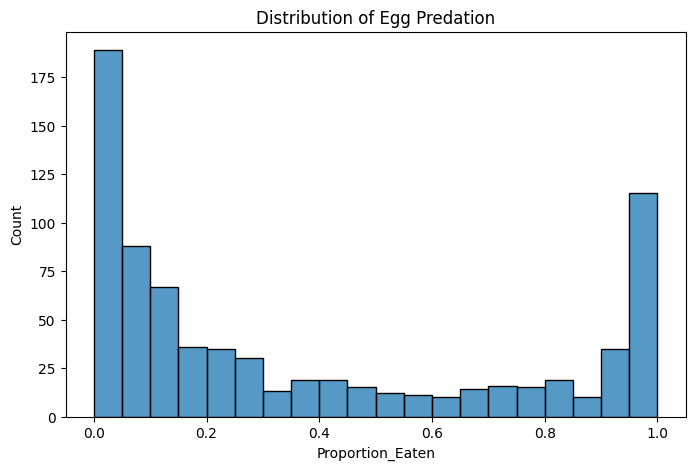

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Proportion_Eaten"], bins=20)

plt.title("Distribution of Egg Predation")

plt.show()

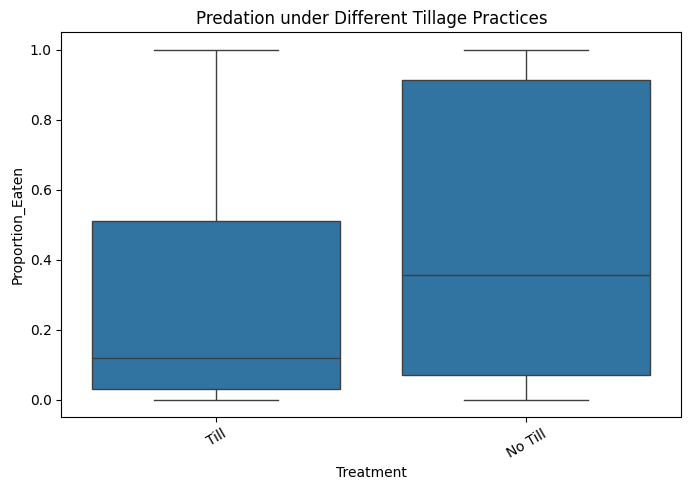

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Treatment",
    y="Proportion_Eaten"
)

plt.xticks(rotation=30)

plt.title("Predation under Different Tillage Practices")

plt.show()

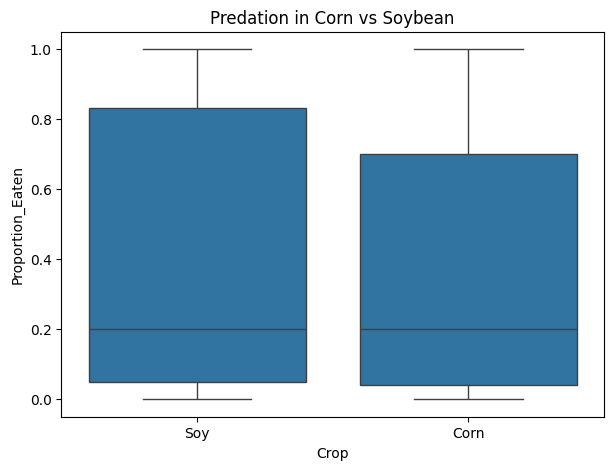

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Crop",
    y="Proportion_Eaten"
)

plt.title("Predation in Corn vs Soybean")

plt.show()

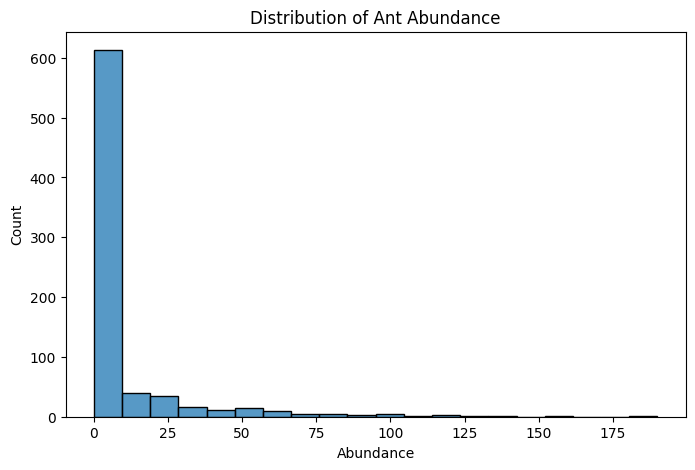

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Abundance"], bins=20)

plt.title("Distribution of Ant Abundance")

plt.show()

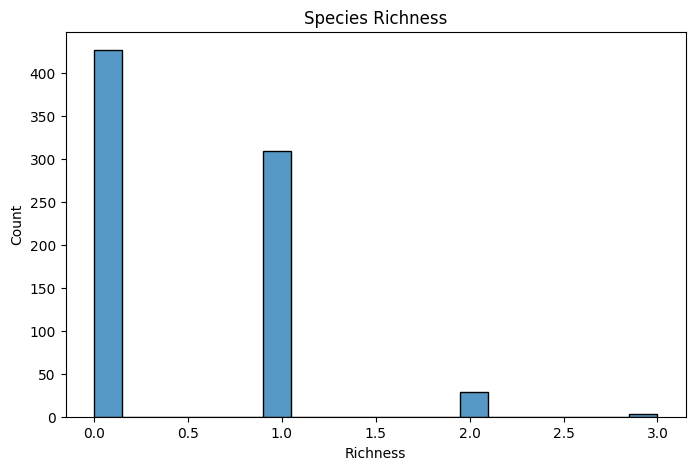

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Richness"], bins=20)

plt.title("Species Richness")

plt.show()

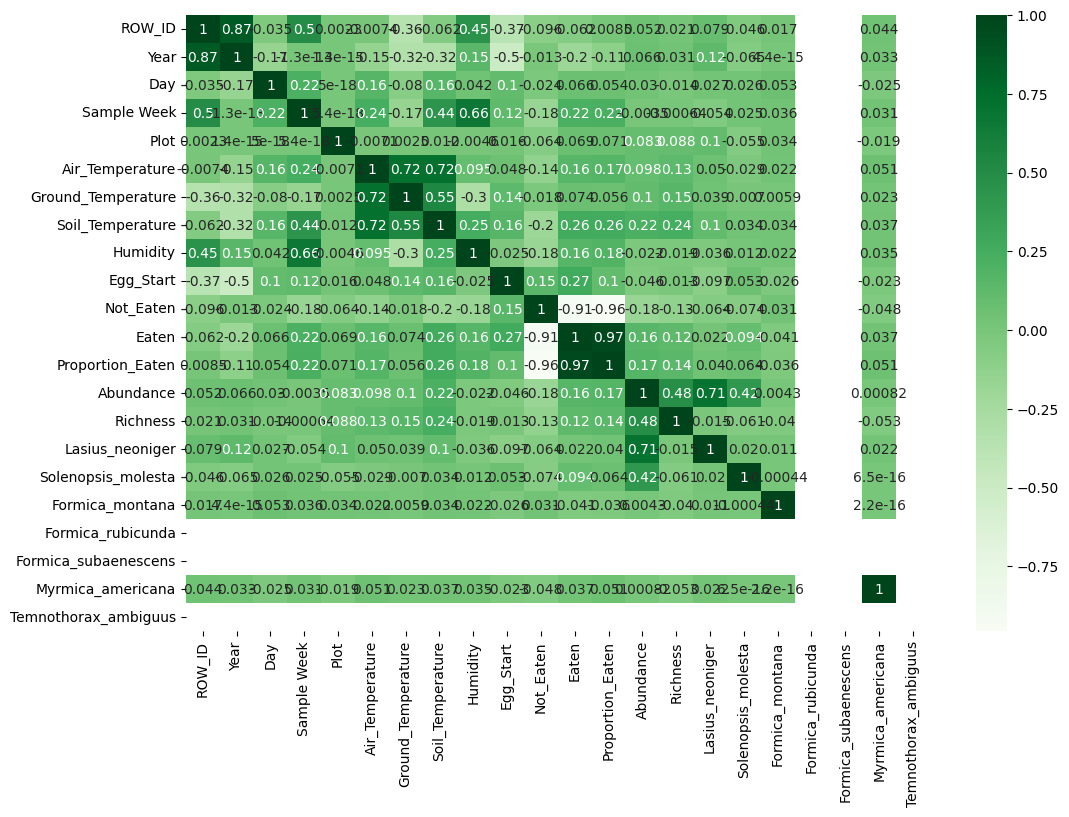

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Greens"
)

plt.show()

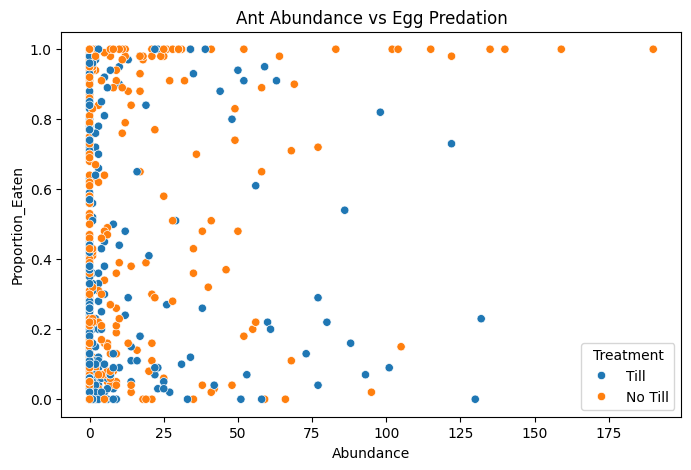

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Abundance",
    y="Proportion_Eaten",
    hue="Treatment"
)

plt.title("Ant Abundance vs Egg Predation")

plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ["Crop","Treatment","Block","Plot"]:
    df[col] = encoder.fit_transform(df[col])

In [23]:
X = df.drop(columns=["Proportion_Eaten"])

y = df["Proportion_Eaten"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(df.select_dtypes(include='object').columns)

Index(['Month'], dtype='object')


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode every column with object (text) datatype
for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

print("Encoding completed!")

Encoding completed!


In [27]:
X = df.drop(columns=[
    "Proportion_Eaten",
    "Egg_Start",
    "Eaten",
    "Not_Eaten"
])

y = df["Proportion_Eaten"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
pred = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", round(mean_absolute_error(y_test, pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))
print("R²  :", round(r2_score(y_test, pred), 3))

MAE : 0.298
RMSE: 0.36
R²  : 0.141


In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
11,Soil_Temperature,0.153225
0,ROW_ID,0.139361
12,Humidity,0.129193
9,Air_Temperature,0.101797
10,Ground_Temperature,0.100289
4,Sample Week,0.061387
6,Treatment,0.056040
13,Abundance,0.048346
7,Block,0.046621
15,Lasius_neoniger,0.041240


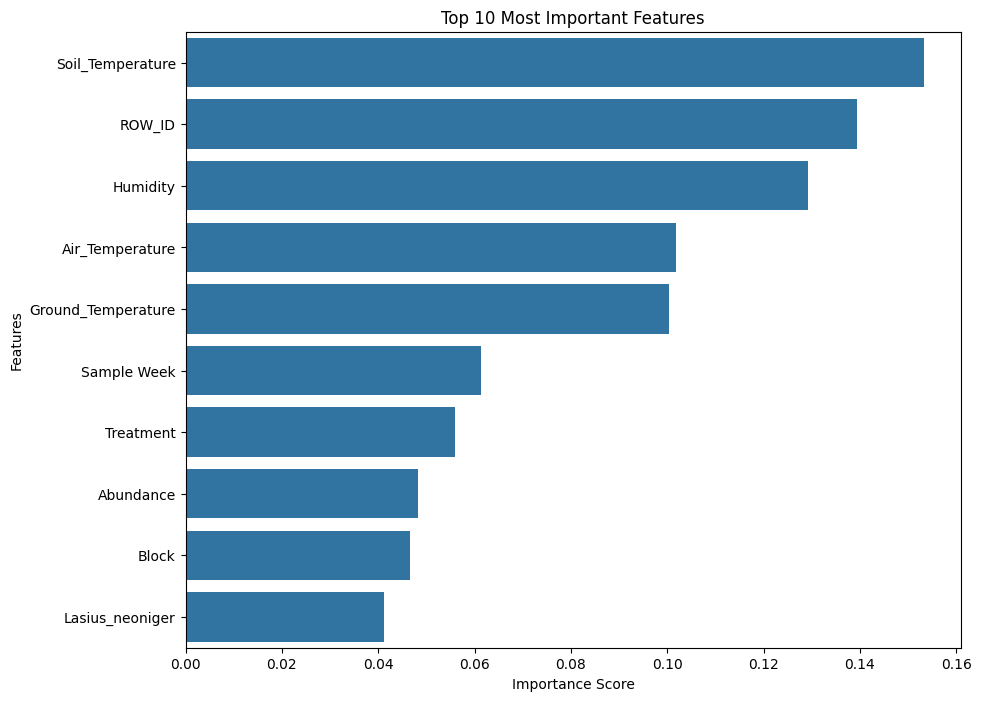

In [33]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

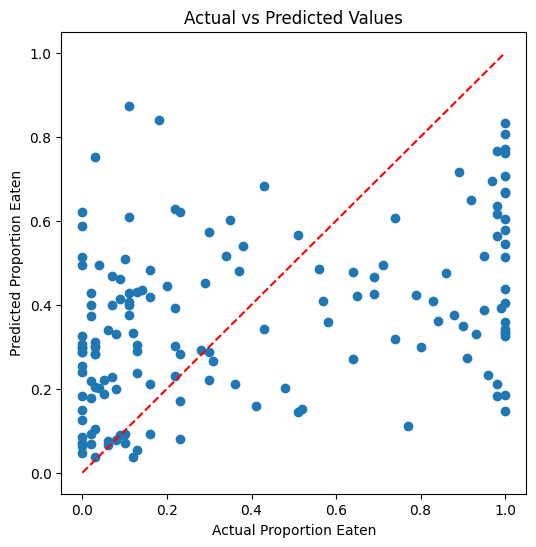

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Proportion Eaten")
plt.ylabel("Predicted Proportion Eaten")
plt.title("Actual vs Predicted Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", round(mean_absolute_error(y_test, pred),3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,pred)),3))
print("R²  :", round(r2_score(y_test,pred),3))

MAE : 0.298
RMSE: 0.36
R²  : 0.141


**Model Performance**


**Metric	Value	Interpretation (MAE):**
	0.298	On average, the predicted predation proportion differs from the true value by about 0.30.

**RMSE:**	0.360	The model has a moderate prediction error, with larger errors penalized more heavily.

**R²:**	0.141	The model explains about 14.1% of the variation in egg predation. This indicates a weak-to-moderate predictive relationship, which is common for ecological field studies.

**Biological Interpretation**

Tillage practices and environmental conditions influence ant-mediated pest predation, but they are not the only factors.

Other variables—such as rainfall, surrounding vegetation, predator interactions, or seasonal dynamics—likely also affect predation rates but are not included in the dataset.

The model still provides useful insights into which measured variables are most associated with biological pest control.